In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys, pathlib

# adjust this to your repo root if different
repo_root = pathlib.Path.cwd()

# If running from the playground directory, move up one level to the repo root
if repo_root.name == 'playground':
    repo_root = repo_root.parent

sys.path.insert(0, str(repo_root))
print('Inserted repo root into sys.path:', repo_root)

Inserted repo root into sys.path: /home/ubuntu/qecsim


In [3]:
from src.codes.surface_code_rotated.builder import SurfaceBuilder
from src.core.data_models import NoiseParameters


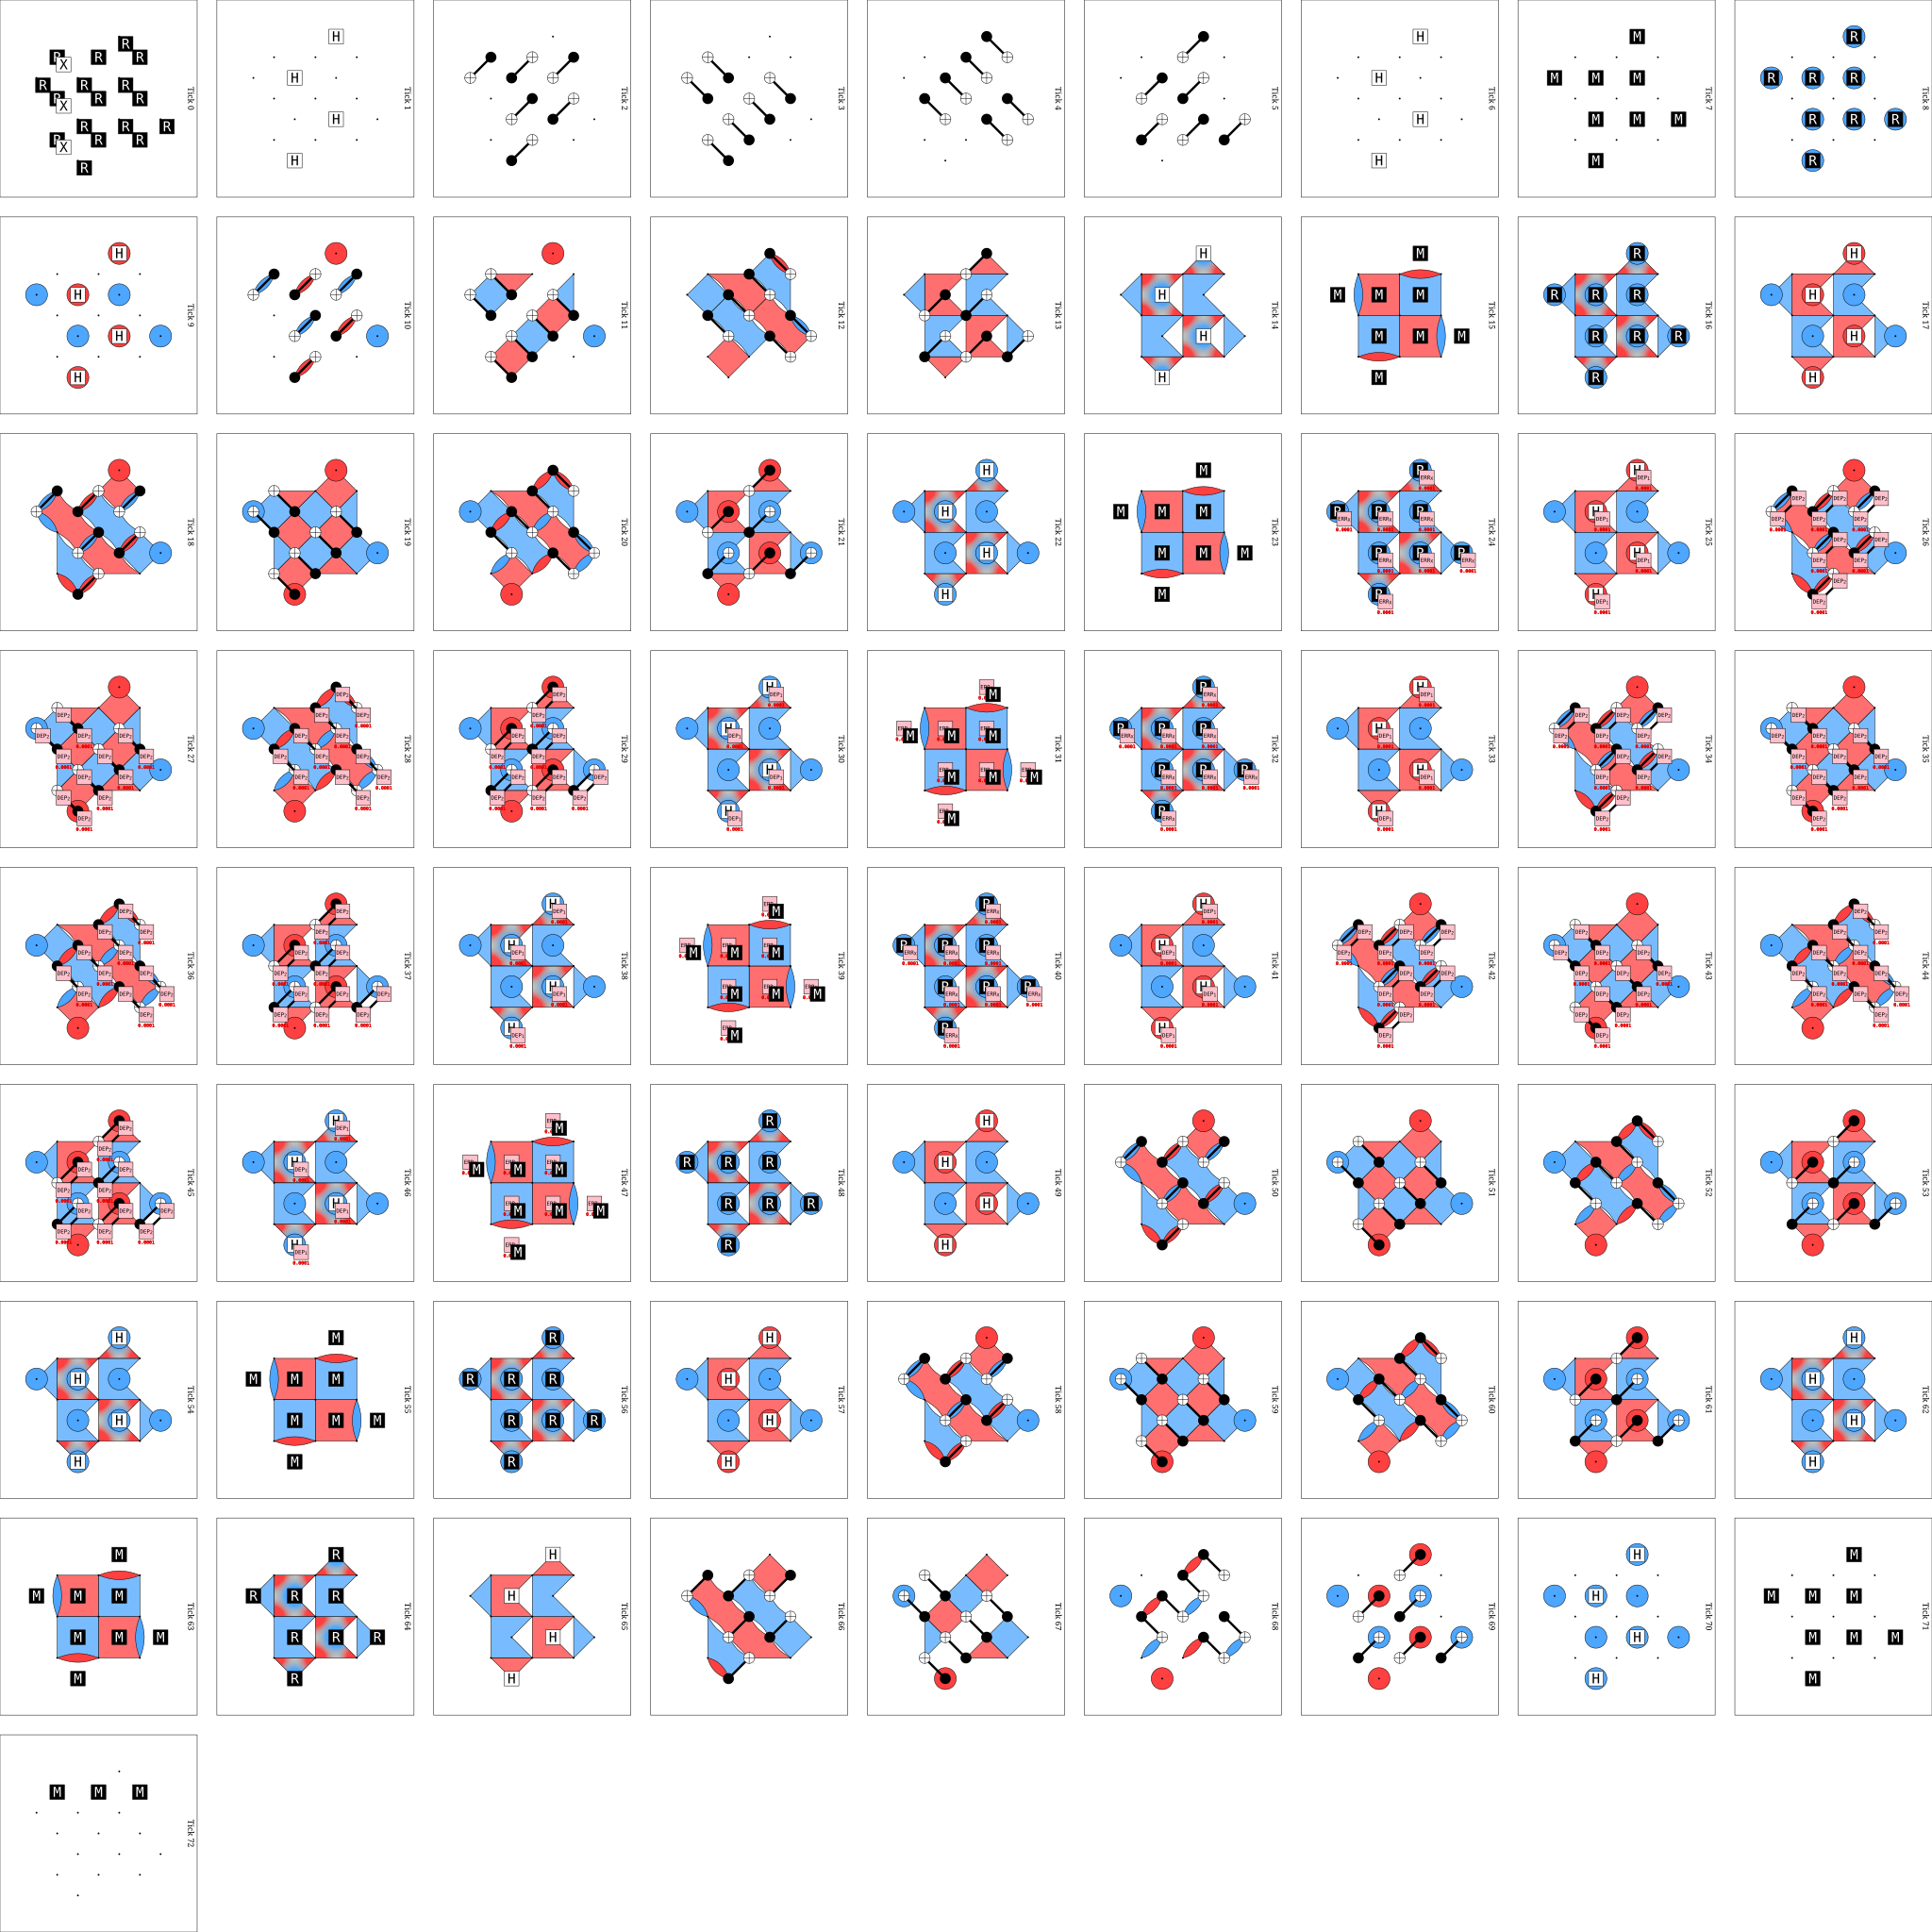

In [4]:
noise = 1e-4

noise_class_circuit = NoiseParameters(before_m_flip_prob=noise,
                              after_r_flip=noise,
                              after_c_depol_prob=noise,
                              before_round_depol=noise)

build = SurfaceBuilder(distance=3, state_init="I1", log_obs="Z", noise=noise_class_circuit)

circuit = build.build_circuit()

circuit.diagram("detslice-with-ops-svg")

In [18]:
# Get Threshold
import itertools
from tqdm import tqdm
import sinter
import math
import os

# geomspace replacement
geom = [10**(math.log10(1e-5) + i*(math.log10(1e-3) - math.log10(1e-5))/9) for i in range(10)]

# linspace replacement
lin = [1.1e-3 + i*(0.015 - 1.1e-3)/39 for i in range(40)]

p_values = geom + lin

distances = [3, 5, 7]

combinations = list(itertools.product(distances, p_values))

# 3. Build the tasks with a progress bar
tasks = [
    sinter.Task(
        circuit= SurfaceBuilder(
            distance= d, 
            state_init="0", 
            log_obs="Z", 
            noise= NoiseParameters(
                before_m_flip_prob=noise,
                after_r_flip=noise,
                after_c_depol_prob=noise,
                before_round_depol=noise
            )
        ).build_circuit(),
        json_metadata={'d': d, 'p': noise},
    )
    for d, noise in tqdm(combinations, desc="Building Circuits")
]

# 4. Now hand them off to sinter
collected_stats = sinter.collect(
    num_workers=os.cpu_count(),
    tasks=tasks,
    decoders=['pymatching'],
    max_shots=1_000_000,
    max_errors=10_000,
    print_progress=True
)

Building Circuits:   0%|          | 0/150 [00:00<?, ?it/s]

Building Circuits: 100%|██████████| 150/150 [00:21<00:00,  6.95it/s]
Starting 64 workers...
150 tasks left:
  workers    decoder eta shots_left errors_left json_metadata               
        1 pymatching   ?    1000000       10000 d=3,p=1e-05                 
        1 pymatching   ?    1000000       10000 d=3,p=1.6681005372000593e-05
        1 pymatching <1m     975151       10000 d=3,p=2.782559402207126e-05 
        1 pymatching   ?    1000000       10000 d=3,p=4.641588833612782e-05 
        1 pymatching   ?    1000000       10000 d=3,p=7.742636826811278e-05 
        1 pymatching   ?    1000000       10000 d=3,p=0.0001291549665014884 
        1 pymatching   ?    1000000       10000 d=3,p=0.00021544346900318823
        1 pymatching   ?    1000000       10000 d=3,p=0.00035938136638046257
        1 pymatching   ?    1000000       10000 d=3,p=0.0005994842503189409 
        1 pymatching   ?    1000000       10000 d=3,p=0.001                 
        1 pymatching   ?    1000000       100

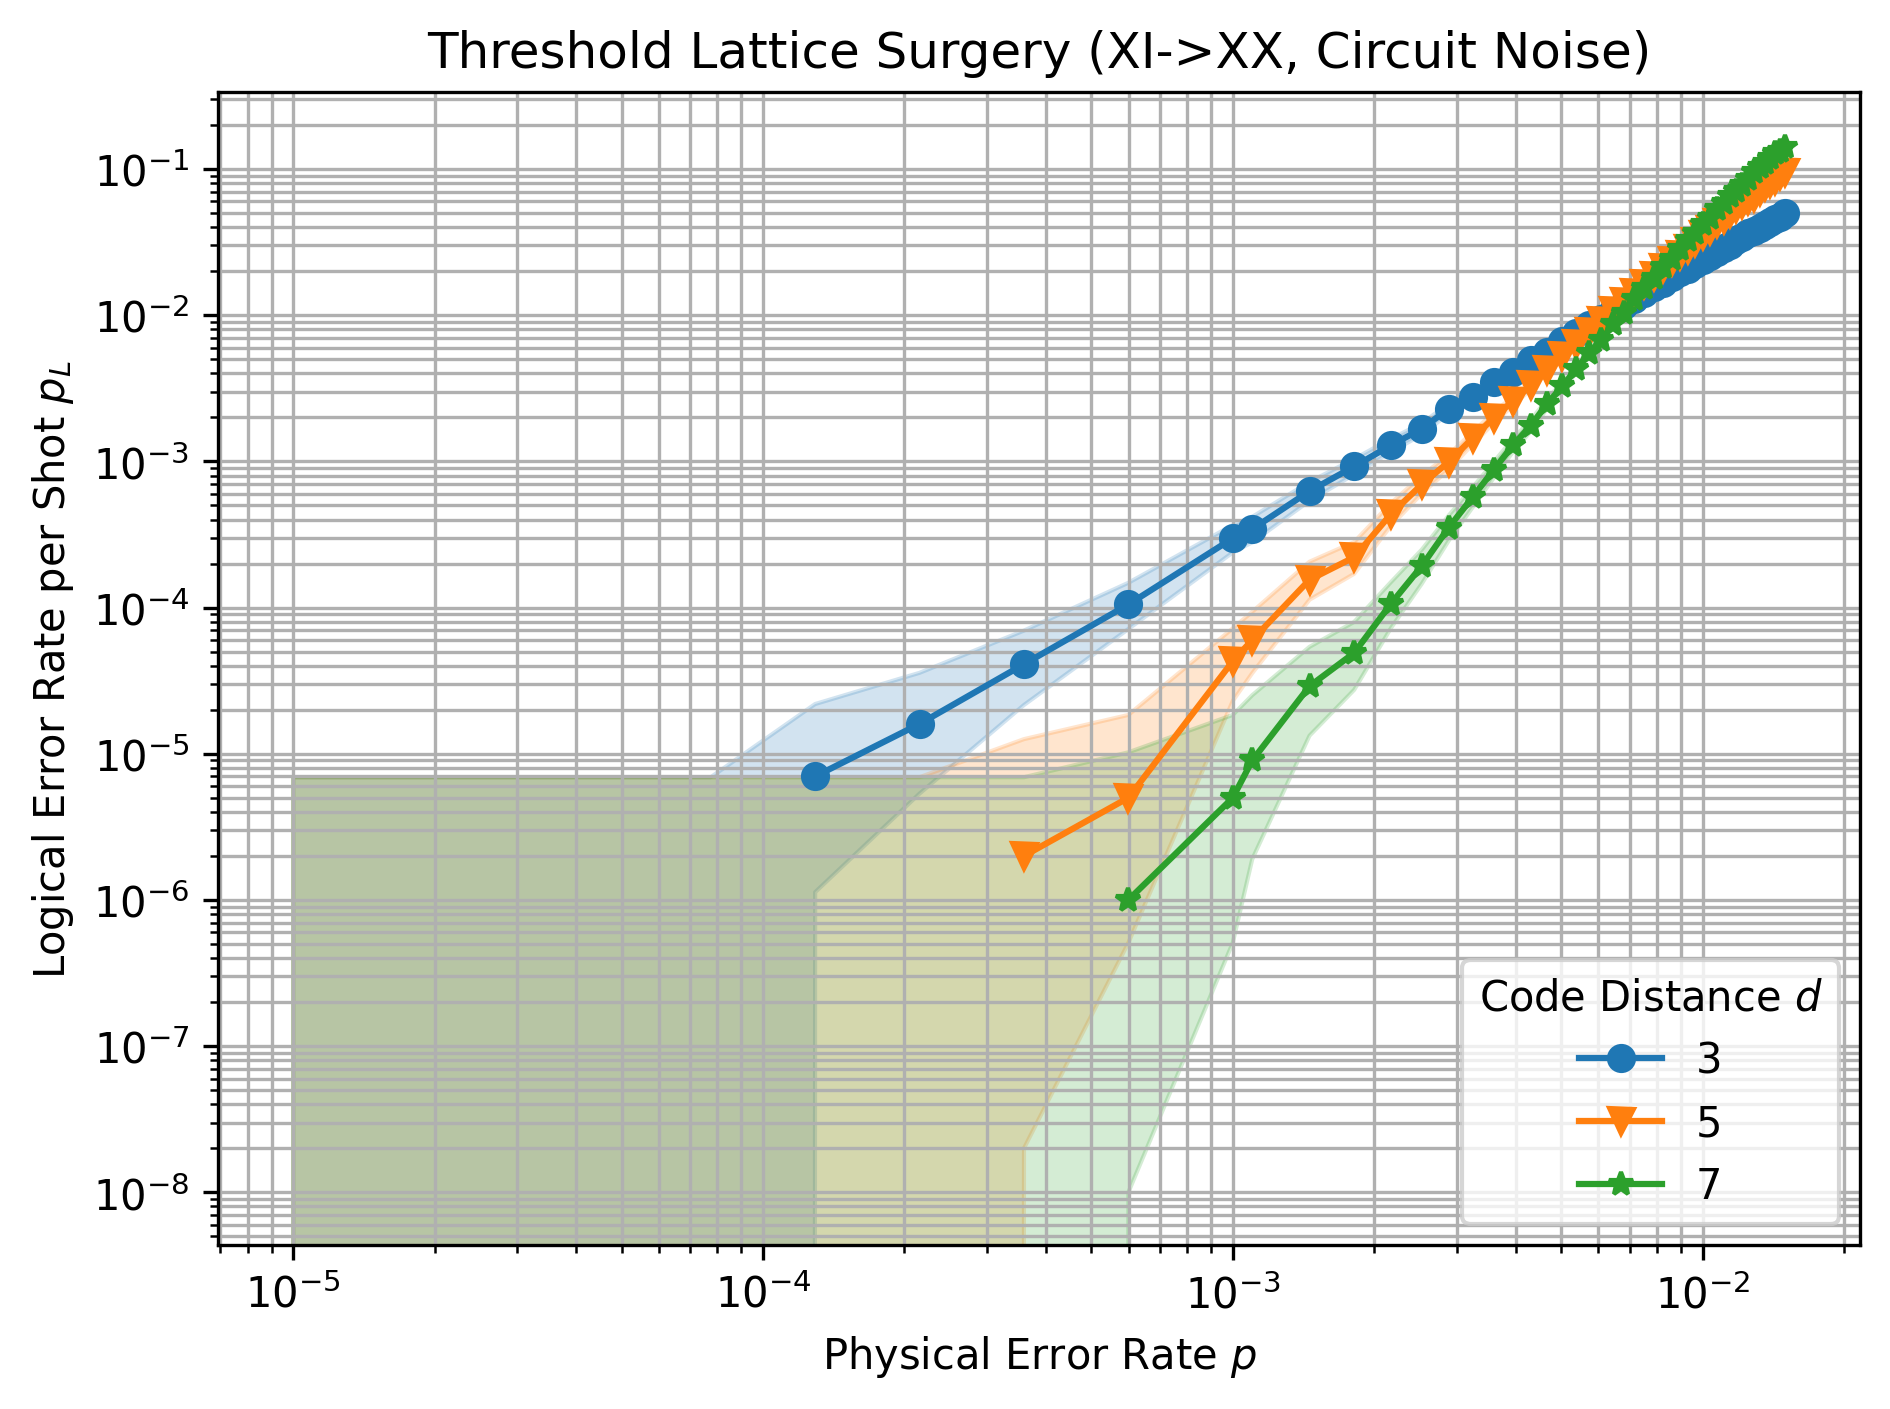

In [19]:
from matplotlib import pyplot as plt

############################################
# Main Plot: Error Rates (Phenomenological)
############################################

fig, ax = plt.subplots(1, 1)

sinter.plot_error_rate(
    ax=ax,
    stats=collected_stats,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['d']
)

# Style main axes
ax.loglog()
ax.set_title("Threshold Lattice Surgery (XI->XX, Circuit Noise)")
ax.set_xlabel("Physical Error Rate $p$")
ax.set_ylabel("Logical Error Rate per Shot $p_L$")
ax.grid(which='major')
ax.grid(which='minor')

# Legend in the bottom right
ax.legend(title="Code Distance $d$", loc='lower right')

# Final figure settings
fig.set_dpi(300)
plt.tight_layout()

# Show the plot
plt.show()

In [5]:
from src.codes.lattice_surgery.builder import SurgeryBuilder

**TODO**

- Current Y Observables do not seem to cahnge the measurement outcome when flipped which makes no sense
    - Happens for fault tolerant as well as non fualt tolerant procedure
- Implmented resets on all qubits in non-ft mode but thats total bullshit, makes no sense

In [48]:
noise = 1e-4

noise_class_bias = NoiseParameters(before_m_flip_prob=noise,
                              after_r_flip=noise,
                              after_c_pauli_channel_prob=noise,
                              noise_bias=[0.1, 0.1, 0.8])

noise_class_circuit = NoiseParameters(before_m_flip_prob=noise,
                              after_r_flip=noise,
                              after_c_depol_prob=noise,
                              before_round_depol=noise)


test_surgery_builder = SurgeryBuilder(distance=7, control_state_init="X+", target_state_init="I0",
                                      control_measure_basis="X", target_measure_basis="X", noise= noise_class_circuit)

test_surgery_circuit = test_surgery_builder.build_circuit()

# print(test_surgery_circuit.shortest_graphlike_error())
print(len(test_surgery_circuit.shortest_graphlike_error()))

test_surgery_circuit#.diagram("detslice-with-ops-svg", filter_coords=["D330", "D339"], tick= range(195,210))

7


stim.Circuit('''
    QUBIT_COORDS(0, 2) 0
    QUBIT_COORDS(0, 6) 1
    QUBIT_COORDS(0, 10) 2
    QUBIT_COORDS(0, 14) 3
    QUBIT_COORDS(0, 18) 4
    QUBIT_COORDS(0, 22) 5
    QUBIT_COORDS(0, 26) 6
    QUBIT_COORDS(1, 1) 7
    QUBIT_COORDS(1, 3) 8
    QUBIT_COORDS(1, 5) 9
    QUBIT_COORDS(1, 7) 10
    QUBIT_COORDS(1, 9) 11
    QUBIT_COORDS(1, 11) 12
    QUBIT_COORDS(1, 13) 13
    QUBIT_COORDS(1, 15) 14
    QUBIT_COORDS(1, 17) 15
    QUBIT_COORDS(1, 19) 16
    QUBIT_COORDS(1, 21) 17
    QUBIT_COORDS(1, 23) 18
    QUBIT_COORDS(1, 25) 19
    QUBIT_COORDS(1, 27) 20
    QUBIT_COORDS(2, 2) 21
    QUBIT_COORDS(2, 4) 22
    QUBIT_COORDS(2, 6) 23
    QUBIT_COORDS(2, 8) 24
    QUBIT_COORDS(2, 10) 25
    QUBIT_COORDS(2, 12) 26
    QUBIT_COORDS(2, 14) 27
    QUBIT_COORDS(2, 16) 28
    QUBIT_COORDS(2, 18) 29
    QUBIT_COORDS(2, 20) 30
    QUBIT_COORDS(2, 22) 31
    QUBIT_COORDS(2, 24) 32
    QUBIT_COORDS(2, 26) 33
    QUBIT_COORDS(3, 1) 34
    QUBIT_COORDS(3, 3) 35
    QUBIT_COORDS(3, 5) 36
    QUBI

In [39]:
test_surgery_builder = SurgeryBuilder(distance=3, control_state_init="I0", target_state_init="X+",
                                      control_measure_basis="I", target_measure_basis="X", noise= noise_class_circuit)

test_surgery_circuit = test_surgery_builder.build_circuit()

len(test_surgery_circuit.shortest_graphlike_error())

238


3

In [45]:
import sinter
import os
import math
import itertools
from tqdm import tqdm

In [ ]:
# geomspace replacement
geom = [10**(math.log10(1e-5) + i*(math.log10(1e-3) - math.log10(1e-5))/9) for i in range(10)]

# linspace replacement
lin = [1.1e-3 + i*(0.015 - 1.1e-3)/39 for i in range(40)]

p_values = geom + lin

distances = [3, 5]

combinations = list(itertools.product(distances, p_values))

# 3. Build the tasks with a progress bar
tasks = [
    sinter.Task(
        circuit=SurgeryBuilder(
            distance=d,
            control_state_init="X+",
            target_state_init="I0",
            control_measure_basis="X",
            target_measure_basis="X",
            noise=NoiseParameters(
                before_round_depol=noise,
                before_m_flip_prob=noise,
                after_r_flip=noise,
                after_c_depol_prob=noise
            )
        ).build_circuit(),
        json_metadata={'d': d, 'p': noise},
    )
    for d, noise in tqdm(combinations, desc="Building Circuits")
]

# 4. Now hand them off to sinter
collected_stats = sinter.collect(
    num_workers=os.cpu_count(),
    tasks=tasks,
    decoders=['pymatching'],
    max_shots=10_000_000,
    max_errors=100_000,
    print_progress=True
)

Building Circuits:   0%|          | 0/100 [00:00<?, ?it/s]

Building Circuits:   1%|          | 1/100 [00:00<00:19,  5.18it/s]

101
101


Building Circuits:   3%|▎         | 3/100 [00:00<00:16,  5.72it/s]

101
101


...

Building Circuits:  98%|█████████▊| 98/100 [00:55<00:01,  1.02it/s]

267


Building Circuits:  99%|█████████▉| 99/100 [00:56<00:00,  1.03it/s]

267


Building Circuits: 100%|██████████| 100/100 [00:57<00:00,  1.75it/s]
Starting 64 workers...
100 tasks left:
  workers    decoder eta shots_left errors_left json_metadata               
        1 pymatching   ?    1000000       10000 d=3,p=1e-05                 
        1 pymatching   ?    1000000       10000 d=3,p=1.6681005372000593e-05
        1 pymatching   ?    1000000       10000 d=3,p=2.782559402207126e-05 
        1 pymatching   ?    1000000       10000 d=3,p=4.641588833612782e-05 
        1 pymatching   ?    1000000       10000 d=3,p=7.742636826811278e-05 
        1 pymatching   ?    1000000       10000 d=3,p=0.0001291549665014884 
        1 pymatching   ?    1000000       10000 d=3,p=0.00021544346900318823
        1 pymatching   ?    1000000       10000 d=3,p=0.00035938136638046257
        1 pymatching   ?    1000000       10000 d=3,p=0.0005994842503189409 
        1 pymatching   ?    1000000       10000 d=3,p=0.001                 
        1 pymatching   ?    1000000       100

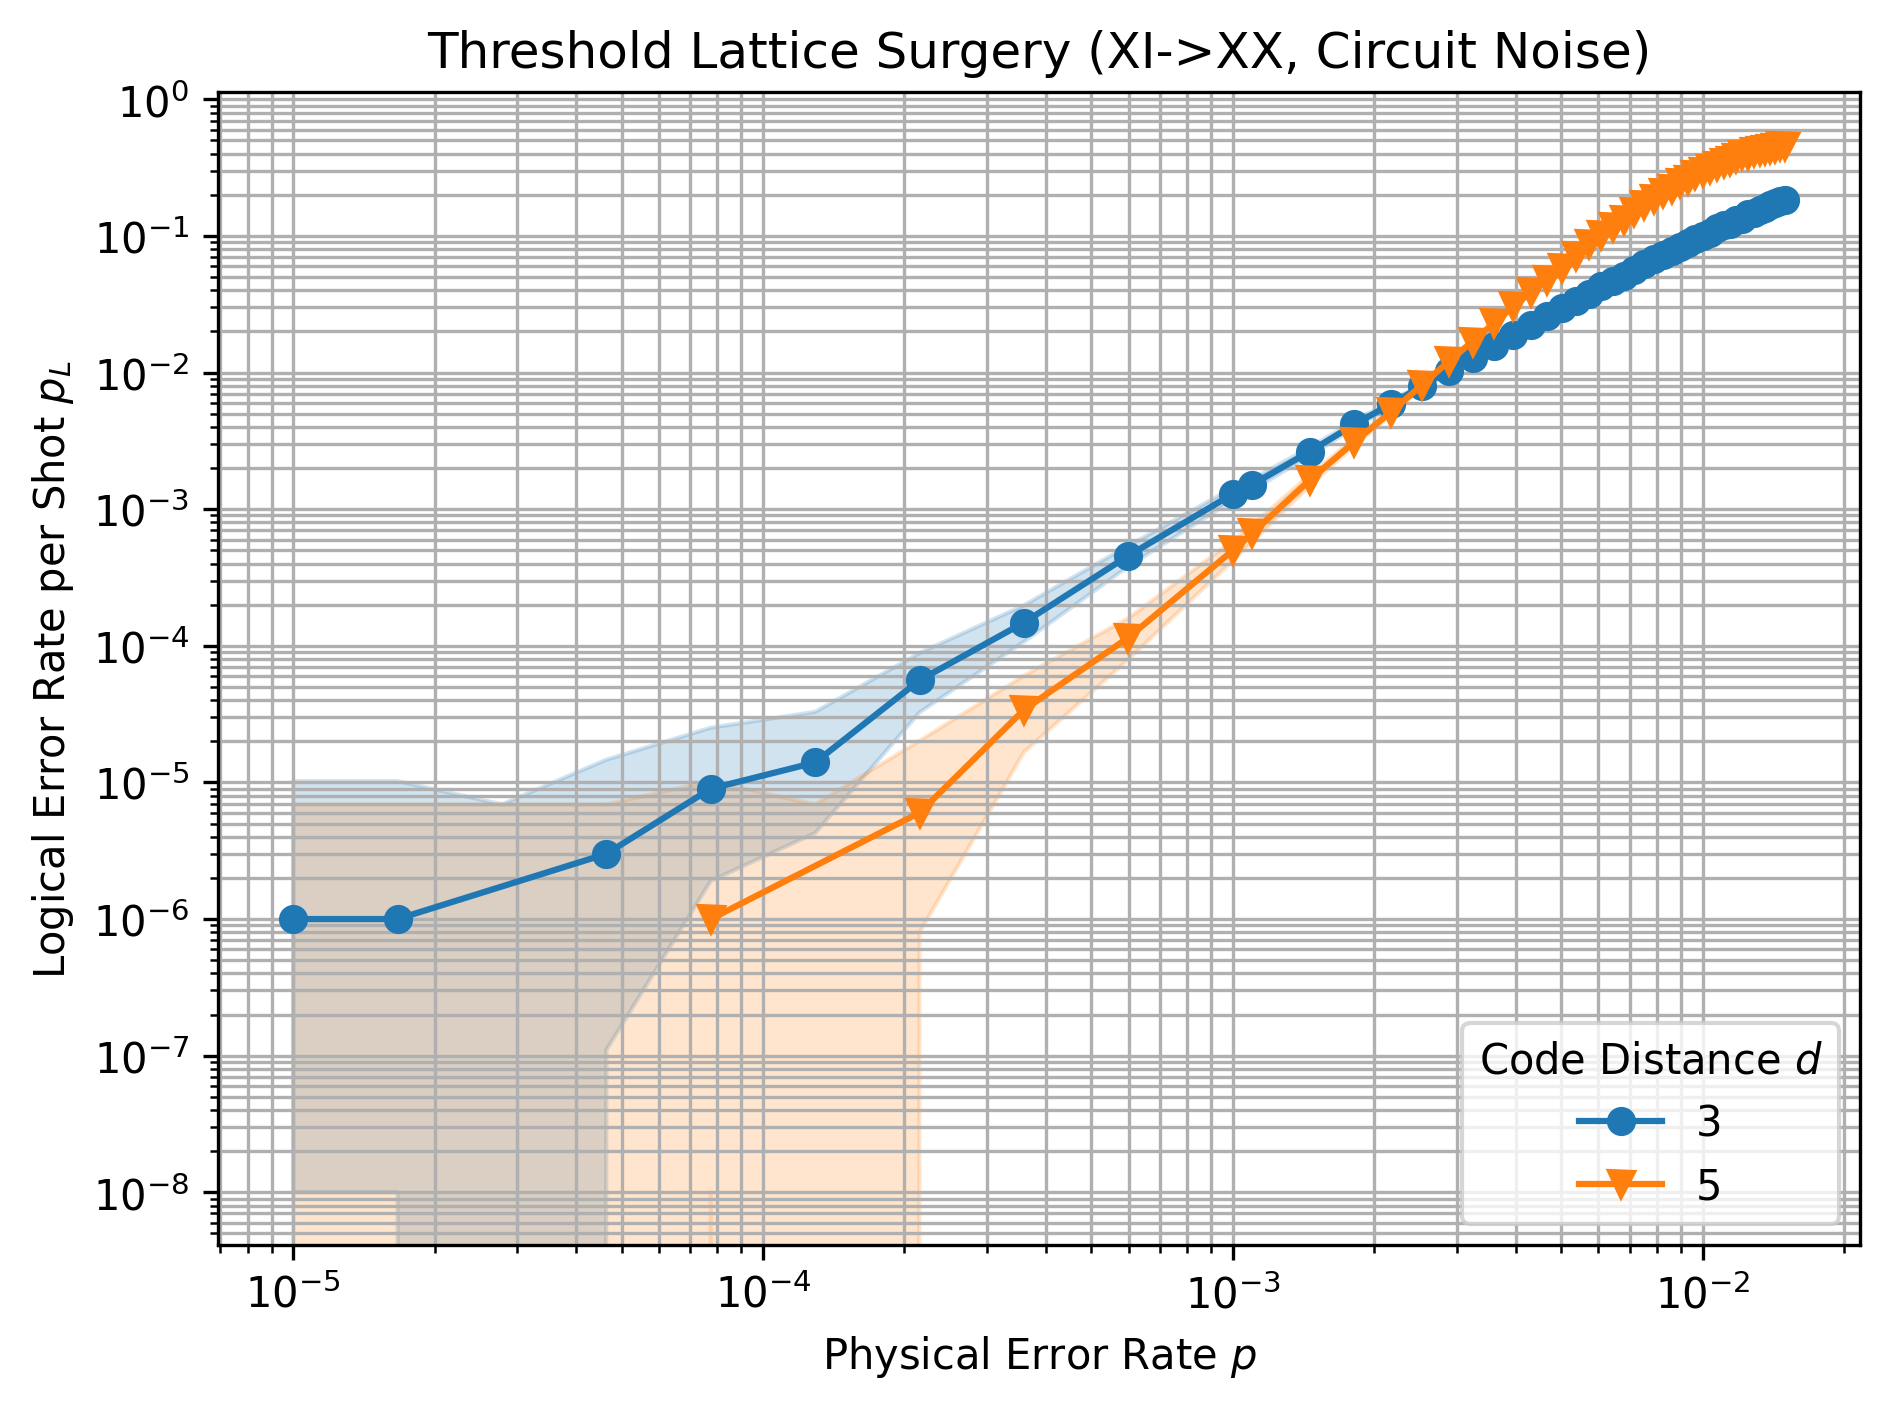

In [47]:
############################################
# Main Plot: Error Rates (Phenomenological)
############################################

from matplotlib import pyplot as plt

fig, ax = plt.subplots(1, 1)

sinter.plot_error_rate(
    ax=ax,
    stats=collected_stats,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['d']
)

# Style main axes
ax.loglog()
ax.set_title("Threshold Lattice Surgery (XI->XX, Circuit Noise)")
ax.set_xlabel("Physical Error Rate $p$")
ax.set_ylabel("Logical Error Rate per Shot $p_L$")
ax.grid(which='major')
ax.grid(which='minor')

# Legend in the bottom right
ax.legend(title="Code Distance $d$", loc='lower right')

# Final figure settings
fig.set_dpi(300)
plt.tight_layout()

# Show the plot
plt.show()